<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Домашнее задание. Обучение языковой модели с помощью LSTM (10 баллов)

Э
В этом задании Вам предстоит обучить языковую модель с помощью рекуррентной нейронной сети. В отличие от семинарского занятия, Вам необходимо будет работать с отдельными словами, а не буквами.


Установим модуль ```datasets```, чтобы нам проще было работать с данными.

In [139]:
!pip install datasets

Импорт необходимых библиотек

In [140]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import string

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List

import seaborn
seaborn.set(palette='summer')

In [141]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [142]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Подготовка данных

Воспользуемся датасетом imdb. В нем хранятся отзывы о фильмах с сайта imdb. Загрузим данные с помощью функции ```load_dataset```

In [143]:
# Загрузим датасет
dataset = load_dataset('imdb')

### Препроцессинг данных и создание словаря (1 балл)

Далее вам необходмо самостоятельно произвести препроцессинг данных и получить словарь или же просто ```set``` строк. Что необходимо сделать:

1. Разделить отдельные тренировочные примеры на отдельные предложения с помощью функции ```sent_tokenize``` из бибилиотеки ```nltk```. Каждое отдельное предложение будет одним тренировочным примером.
2. Оставить только те предложения, в которых меньше ```word_threshold``` слов.
3. Посчитать частоту вхождения каждого слова в оставшихся предложениях. Для деления предлоения на отдельные слова удобно использовать функцию ```word_tokenize```.
4. Создать объект ```vocab``` класса ```set```, положить в него служебные токены '\<unk\>', '\<bos\>', '\<eos\>', '\<pad\>' и vocab_size самых частовстречающихся слов.   

In [144]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [145]:
sentences = []
word_threshold = 32

# Получить отдельные предложения и поместить их в sentences
for sentence in tqdm(dataset['train']['text']):
  sentences.extend(
    [x.lower() for x in sent_tokenize(sentence) if len(x) < word_threshold]
  )

  0%|          | 0/25000 [00:00<?, ?it/s]

In [146]:
print("Всего предложений:", len(sentences))

Всего предложений: 28827


Посчитаем для каждого слова его встречаемость.

In [147]:
stop_words_set = set(stopwords.words('english'))
punctuation_set = set(string.punctuation)

In [148]:
words = Counter()

# Расчет встречаемости слов c фильтрацией
for sentence in tqdm(sentences):
  word_tokens = word_tokenize(sentence)
  filtered_tokens = [word.lower() for word in word_tokens if not word.lower() in stop_words_set and not word in punctuation_set]
  for word in filtered_tokens:
    words[word] += 1

  0%|          | 0/28827 [00:00<?, ?it/s]

In [149]:
words = Counter()

# Расчет встречаемости слов без фильтрацией
for sentence in tqdm(sentences):
  word_tokens = word_tokenize(sentence)
  for word in word_tokens:
    words[word] += 1

  0%|          | 0/28827 [00:00<?, ?it/s]

In [150]:
len(words)

9652

In [151]:
N = 15
top_n = words.most_common(N)
top_n

[('.', 18593),
 ('!', 6816),
 ('it', 4088),
 ('?', 3781),
 ('the', 3227),
 ('is', 3217),
 ('i', 3109),
 ('a', 2818),
 (',', 2456),
 ('this', 2286),
 ("'s", 1720),
 ('was', 1620),
 ('movie', 1280),
 ('and', 1255),
 ("n't", 1233)]

Добавим в словарь ```vocab_size``` самых встречающихся слов.

In [152]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
vocab_size = 8000
top_words = words.most_common(vocab_size)

# Наполнение словаря
for word, _ in tqdm(top_words):
  vocab.add(word)

  0%|          | 0/8000 [00:00<?, ?it/s]

In [153]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [154]:
print("Всего слов в словаре:", len(vocab))

Всего слов в словаре: 8004


### Подготовка датасета (1 балл)

Далее, как и в семинарском занятии, подготовим датасеты и даталоадеры.

В классе ```WordDataset``` вам необходимо реализовать метод ```__getitem__```, который будет возвращать сэмпл данных по входному idx, то есть список целых чисел (индексов слов).

Внутри этого метода необходимо добавить служебные токены начала и конца последовательности, а также токенизировать соответствующее предложение с помощью ```word_tokenize``` и сопоставить ему индексы из ```word2ind```.

In [155]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

In [156]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        # Допишите код здесь
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in word_tokenize(self.data[idx])]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [157]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

In [158]:
train_sentences, eval_sentences = train_test_split(sentences, test_size=0.2)
eval_sentences, test_sentences = train_test_split(sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

print(train_dataset.__getitem__(42))

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

[1728, 6303, 8000, 2053, 1652, 948, 1290, 2564]


## Обучение и архитектура модели

Вам необходимо на практике проверить, что влияет на качество языковых моделей. В этом задании нужно провести серию экспериментов с различными вариантами языковых моделей и сравнить различия в конечной перплексии на тестовом множестве.

Возмоэные идеи для экспериментов:

* Различные RNN-блоки, например, LSTM или GRU. Также можно добавить сразу несколько RNN блоков друг над другом с помощью аргумента num_layers. Вам поможет официальная документация [здесь](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
* Различные размеры скрытого состояния. Различное количество линейных слоев после RNN-блока. Различные функции активации.
* Добавление нормализаций в виде Dropout, BatchNorm или LayerNorm
* Различные аргументы для оптимизации, например, подбор оптимального learning rate или тип алгоритма оптимизации SGD, Adam, RMSProp и другие
* Любые другие идеи и подходы

После проведения экспериментов необходимо составить таблицу результатов, в которой описан каждый эксперимент и посчитана перплексия на тестовом множестве.

Учтите, что эксперименты, которые различаются, например, только размером скрытого состояния или количеством линейных слоев считаются, как один эксперимент.

Успехов!

### Функция evaluate (1 балл)

Заполните функцию ```evaluate```

In [159]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

### Train loop (1 балл)

Напишите функцию для обучения модели.

In [160]:
def train_model(model, optimizer, criterion, num_epoch=25):
    losses = []
    perplexities = []

    for epoch in range(num_epoch):
        epoch_losses = []
        model.train()
        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(
                logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(sum(epoch_losses) / len(epoch_losses))
        perplexities.append(evaluate(model, criterion, eval_dataloader))
    return losses, perplexities

### Первый эксперимент (2 балла)

Определите архитектуру модели и обучите её.

In [161]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.projection = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(output)  # [batch_size, seq_len, vocab_size]

        return projection

In [162]:
model1 = LanguageModel(hidden_dim=256, vocab_size=len(vocab)).to(device)
optimizer1 = torch.optim.Adam(model1.parameters())
criterion1 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

In [163]:
losses, perplexities = train_model(model1, optimizer1, criterion1, num_epoch= 45)

Training epoch 0::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/181 [00:00<?, ?it/s]

...

Training epoch 40::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 41::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 42::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 43::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 44::   0%|          | 0/181 [00:00<?, ?it/s]

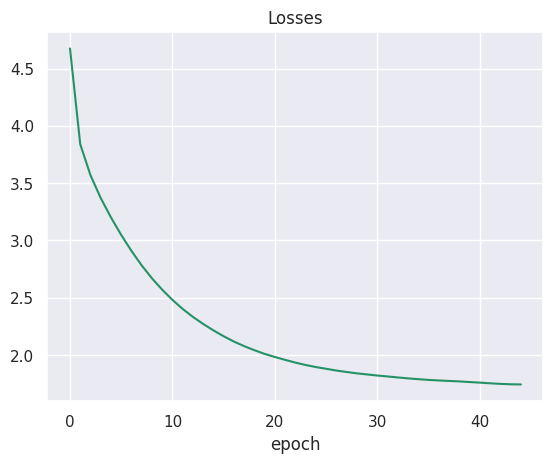

In [164]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

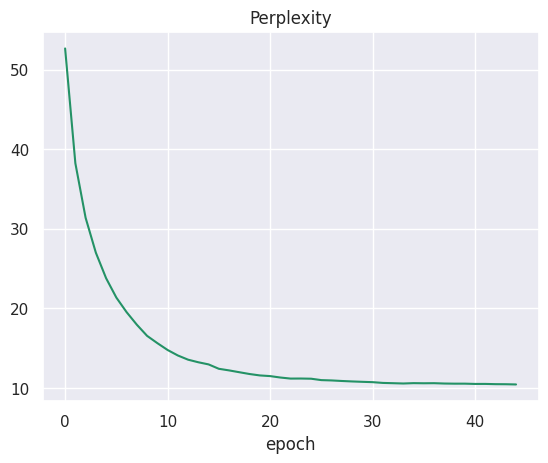

In [165]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

### Второй эксперимент (2 балла)

Попробуйте что-то поменять в модели или в пайплайне обучения, идеи для экспериментов можно подсмотреть выше.

In [166]:
class LanguageModel2(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim//2)
        self.projection = nn.Linear(hidden_dim//2, vocab_size)


        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.15)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)
        output, _ = self.rnn(embeddings)
        output = self.linear(output)
        output = self.dropout(output)
        output = self.linear2(output)
        projection = self.projection(self.non_lin(output))

        return projection

In [167]:
model2 = LanguageModel2(hidden_dim=256, vocab_size=len(vocab)).to(device)
optimizer2 = torch.optim.Adam(model2.parameters())
criterion2 = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])

In [168]:
losses, perplexities = train_model(model2, optimizer2, criterion2, num_epoch= 70)

Training epoch 0::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/181 [00:00<?, ?it/s]

...

Training epoch 65::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 66::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 67::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 68::   0%|          | 0/181 [00:00<?, ?it/s]

Training epoch 69::   0%|          | 0/181 [00:00<?, ?it/s]

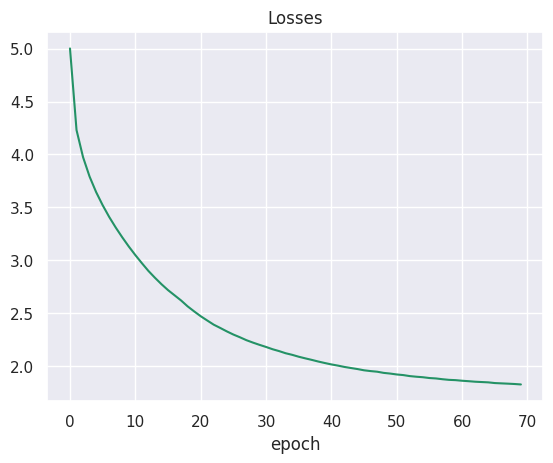

In [169]:
plt.plot(np.arange(len(losses)), losses)
plt.title('Losses')
plt.xlabel("epoch")
plt.show()

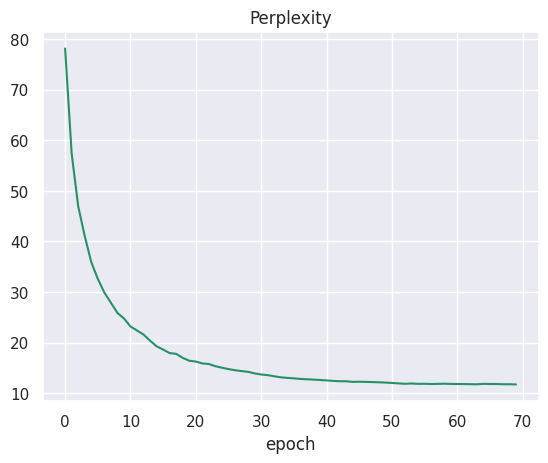

In [170]:
plt.plot(np.arange(len(perplexities)), perplexities)
plt.title('Perplexity')
plt.xlabel("epoch")
plt.show()

### Отчет (2 балла)

Опишите проведенные эксперименты. Сравните перплексии полученных моделей. Предложите идеи по улучшению качества моделей.

| Модель | Тип RNN | Наличие dropout | Дополнительные линейные слои |  Эпизоды обучения | Результаты на test датасете |
|-------------|-------------|----------|-------------|-------------|-------------|
| Модель 1  | GRU  | нет  | нет | 45  | 10.40  |
| Модель 2  | LSTM  | да  | есть | 70  | 11.57  |

In [171]:
score1 = evaluate(model1, criterion1, test_dataloader)
score2 = evaluate(model2, criterion1, test_dataloader)
print(score1)

print(score2)

10.405313597316235
11.575858888372911


Возможно модели недообучены, т.к. при увеличении количества эпох скор на тесте растёт у обеих моделей.